# CensusAnalysis

In [1]:
import pandas as pd
from sodapy import Socrata
import pandas as pd
pd.set_option('display.max_rows', 500)
import geopandas as gpd  
pd.set_option('display.max_columns', None)

/home/joe/anaconda3/envs/bic/lib/python3.6/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.18) or chardet (5.0.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  RequestsDependencyWarning)


In [16]:
df = pd.read_csv("https://data.colorado.gov/resource/vcag-iwy7.csv")

In [17]:
df.head()

,dataset_type,dataset_title,api_id
0,2010_standard,Census Block Groups in Colorado 2010 (https://...,93kh-r488
1,acs_old,Census Block Groups in Colorado 2011 (https://...,ic5a-quwv
2,acs_standard,Census Block Groups in Colorado 2012 (https://...,pgs5-k2ve
3,acs_standard,Census Block Groups in Colorado 2013 (https://...,muph-8jnm
4,acs_standard,Census Block Groups in Colorado 2014 (https://...,adbb-iu37


In [4]:
df["dataset_title"].value_counts()

Census Zip Codes in Colorado 2016 (https://data.colorado.gov/a/b/rwak-e74e)                  1
Census Counties in Colorado 2020 (https://data.colorado.gov/a/b/rt7b-823p)                   1
Census Tracts in Colorado 2020 (https://data.colorado.gov/a/b/7t53-5gfx)                     1
Census Tracts in Colorado 2017 (https://data.colorado.gov/a/b/aevh-apr2)                     1
Census Zip Codes in Colorado 2013 (https://data.colorado.gov/a/b/3ftn-9s6k)                  1
                                                                                            ..
Census Congressional Districts in Colorado 2016 (https://data.colorado.gov/a/b/6fg8-f8c5)    1
Census Places in Colorado 2018 (https://data.colorado.gov/a/b/t2jr-8j7z)                     1
Census State SF3 of Colorado 2000 (https://data.colorado.gov/a/b/fjhv-ruxa)                  1
Census CSA's in Colorado 2010 (https://data.colorado.gov/a/b/33fk-kb5q)                      1
Census Blocks in Colorado 2010 (https://data.color

In [18]:
df2020 = df.loc[df['dataset_title'].str.contains('2020')]
df2019 = df.loc[df['dataset_title'].str.contains('2019')]


In [8]:
for index,row in df2020.iterrows():
    print(row['dataset_title'])

Census Block Groups in Colorado 2020 (https://data.colorado.gov/Demographics/Census-Block-Groups-in-Colorado-2020/jwbw-xb7i)
Census Congressional Districts in Colorado 2020 (https://data.colorado.gov/a/b/q56w-zzzm)
Census Counties in Colorado 2020 (https://data.colorado.gov/a/b/rt7b-823p)
Census in Colorado 2020 (https://data.colorado.gov/a/b/ekih-pydt)
Census Places in Colorado 2020 (https://data.colorado.gov/a/b/33q3-djk8)
Census Tracts in Colorado 2020 (https://data.colorado.gov/a/b/7t53-5gfx)
Census Zip Codes in Colorado 2020 (https://data.colorado.gov/a/b/ucnv-vw74)


In [9]:
display(df2020.head(20))

,dataset_type,dataset_title,api_id
10,acs_standard,Census Block Groups in Colorado 2020 (https://...,jwbw-xb7i
25,acs_different,Census Congressional Districts in Colorado 202...,q56w-zzzm
36,acs_standard,Census Counties in Colorado 2020 (https://data...,rt7b-823p
52,acs_standard,Census in Colorado 2020 (https://data.colorado...,ekih-pydt
63,acs_standard,Census Places in Colorado 2020 (https://data.c...,33q3-djk8
86,acs_standard,Census Tracts in Colorado 2020 (https://data.c...,7t53-5gfx
98,acs_different,Census Zip Codes in Colorado 2020 (https://dat...,ucnv-vw74


acs_standard  Census Block Groups in Colorado 2020 (https://data.colorado.gov/Demographics/Census-Block-Groups-in-Colorado-2020/jwbw-xb7i)

acs_standard  Census Counties in Colorado 2020 (https://data.colorado.gov/a/b/rt7b-823p)

acs_standard  Census in Colorado 2020 (https://data.colorado.gov/a/b/ekih-pydt)

acs_standard  Census Places in Colorado 2020 (https://data.colorado.gov/a/b/33q3-djk8)

acs_standard  Census Tracts in Colorado 2020 (https://data.colorado.gov/a/b/7t53-5gfx)



acs_different Census Congressional Districts in Colorado 2020 (https://data.colorado.gov/a/b/q56w-zzzm)

acs_different Census Zip Codes in Colorado 2020 (https://data.colorado.gov/a/b/ucnv-vw74)


## Get Seed Metadata

In [2]:
cim_url_query = 'data.colorado.gov'
datasets = None

with Socrata(cim_url_query, None) as client:
    datasets = client.datasets()

In [3]:
datasetsTarget = {}
w4x4s = []
dfs = {}
for dataset in datasets:
    if "2020" in dataset["resource"]["name"].lower() and "census" in dataset["resource"]["name"].lower():
            title = dataset['resource']['name']
            w4x4 = dataset['resource']['id']
            print(w4x4,title)
            w4x4s.append(w4x4)
            datasetsTarget[title]=dataset

ucnv-vw74 Census Zip Codes in Colorado 2020
7t53-5gfx Census Tracts in Colorado 2020
q56w-zzzm Census Congressional Districts in Colorado 2020
jwbw-xb7i Census Block Groups in Colorado 2020
rt7b-823p Census Counties in Colorado 2020
33q3-djk8 Census Places in Colorado 2020
ekih-pydt Census in Colorado 2020


In [ ]:
datasetsTarget["Census Zip Codes in Colorado 2020"]

## Compare

In [2]:
def compareData(A,B,C,colT):

    histA={}
    histB={}
    for col in C:
        rowA = A.loc[A[colT] == col].to_dict()
        rowB = B.loc[B[colT] == col].to_dict()


        valsA = {}
        for key,val in rowA.items():
      #      if key != 'the_geom':
            if key != 'geometry':
                
                value = list(val.values())
                valsA[key] = value[0]

        valsB = {}
        for key,val in rowB.items():
            if key != 'the_geom':
                value = list(val.values())
                valsB[key] = value[0]

        for key,valB in valsB.items():
            if valB == 0:
               if key in histB:
                  histB[key]+=1
               else:
                  histB[key]=1

            if key in valsA:
                valA = valsA[key]
                if valA == 0:
                   if key in histA:
                      histA[key]+=1
                   else:
                      histA[key]=1

                if valA != valB:
                    diff = valB-valA
                    if valB != 0:
                       p = abs(diff)/valB
                    else:
                       p = -1
                    
                    
                    
                    if p > 5.:
                        print(col,key,valA,valB,valB-valA,p)
            else:
                print("ROH-ROH ",col,key)
    return histA,histB
            


In [21]:
df2019

,dataset_type,dataset_title,api_id
9,acs_standard,Census Block Groups in Colorado 2019 (https://...,spwe-6ca7
24,acs_different,Census Congressional Districts in Colorado 201...,tbmm-ubn9
35,acs_standard,Census Counties in Colorado 2019 (https://data...,8j3i-rjn4
51,acs_standard,Census in Colorado 2019 (https://data.colorado...,smjm-6h6g
62,acs_standard,Census Places in Colorado 2019 (https://data.c...,xpi4-stak
85,acs_standard,Census Tracts in Colorado 2019 (https://data.c...,cj4m-96y8
97,acs_different,Census Zip Codes in Colorado 2019 (https://dat...,bjhg-77mf


### Zips

In [2]:
zips2021 = pd.read_csv("Census_Zip_Codes_in_Colorado_2021_20240524.csv")
zips2022 = pd.read_csv("Census_Zip_Codes_in_Colorado_2021_20240524.csv")

In [3]:
zips2020 =  pd.read_csv("https://data.colorado.gov/resource/ucnv-vw74.csv")
zips2019 =  pd.read_csv("https://data.colorado.gov/resource/bjhg-77mf.csv")

In [4]:
print(zips2020.shape)
print(zips2022.shape)

(526, 156)
(528, 156)


In [6]:
z19=zips2019['zip_code'].values.tolist()


In [7]:
z20=zips2020['zip_code'].values.tolist()
z21=zips2021['zip_code'].values.tolist()
z22=zips2022['zip_code'].values.tolist()

In [8]:
print("20-21",set(z20)-set(z21))
print("21-20",set(z21)-set(z20))

20-21 {80488, 81038, 81231, 80497, 80477, 80511}
21-20 {80826, 80646, 80266, 81228, 80430, 81046, 80474, 80732}


In [9]:
print("20-19",set(z20)-set(z19))
print("19-20",set(z19)-set(z20))

20-19 set()
19-20 set()


In [10]:
print("20-22",set(z20)-set(z22))
print("22-20",set(z22)-set(z20))

20-22 {80488, 81038, 81231, 80497, 80477, 80511}
22-20 {80826, 80646, 80266, 81228, 80430, 81046, 80474, 80732}


In [11]:
z20diffs = set(z20)-set(z21)
z21diffs = set(z21)-set(z20)

In [16]:
zips20diffs = zips2020.loc[zips2020['zip_code'].isin(z20diffs)]
zips21diffs = zips2021.loc[zips2021['zip_code'].isin(z21diffs)]

In [2]:
dft2020 = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/zip_codes_2020/zip_codes_2020.shp")
dft2021 = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/zip_codes_2021/zip_codes_2021.shp")

#ax2 = dft.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

In [26]:
zt20diffs = set(dft2020['zip_code'].values)-set(dft2021['zip_code'].values)
zt21diffs = set(dft2021['zip_code'].values)-set(dft2020['zip_code'].values)

In [27]:
dft20diffs = dft2020.loc[dft2020['zip_code'].isin(zt20diffs)]
dft21diffs = dft2021.loc[dft2021['zip_code'].isin(zt21diffs)]

In [28]:
dft20diffs.shape

(6, 156)

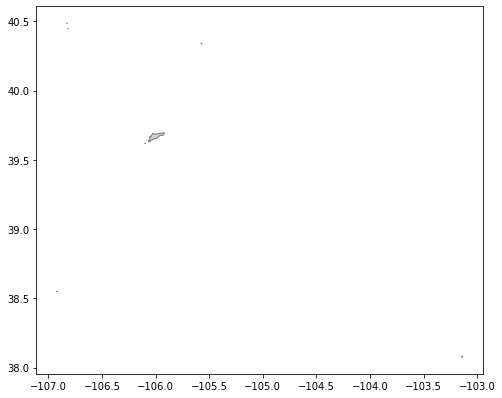

In [29]:
ax2 = dft20diffs.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

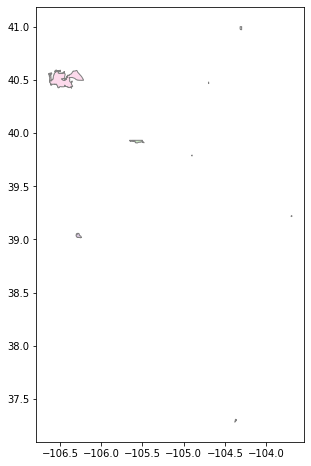

In [30]:
ax2 = dft21diffs.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

In [38]:
dft2020.loc[dft2020['pop'].astype(int) == 0].shape

(12, 156)

In [39]:
dft2021.loc[dft2021['pop'].astype(int) == 0].shape

(15, 156)

In [40]:
zips2019.loc[zips2019['pop'].astype(int) == 0].shape

(13, 156)

In [17]:
zips20diffs.shape

(6, 156)

In [7]:
zall = set(z20).intersection(set(z22))

In [8]:
len(zall)

520

In [ ]:
hA,hB = compareData(zips2020,zips2022,zall,"zip_code")

In [12]:
targ = zips2020.shape[0]
for col,cnt in sorted(hA.items()):
    if cnt/targ > .6: 
        print(col,cnt,targ)

armedfrcs 371 528
hawpi_nh 379 528
other_nh 335 528
pt_other 403 528


In [14]:
targ = zips2022.shape[0]
for col,cnt in sorted(hB.items()):
    if cnt/targ > .5: 
        print(col,cnt,targ)

armedfrcs 360 528
bike 324 528
frm_abroad 269 528
hawpi_nh 385 528
other_nh 291 528
pt_bus 294 528
pt_other 404 528
public_trn 283 528


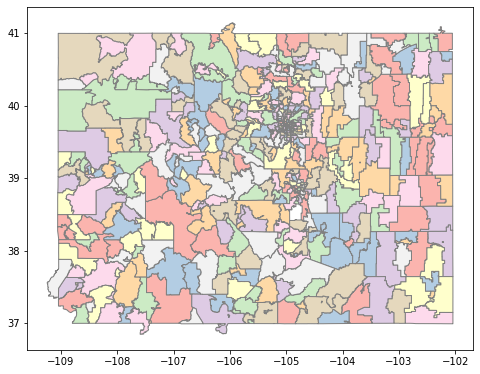

In [15]:
dft = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/zip_codes_2022/zip_codes_2022.shp")
ax2 = dft.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

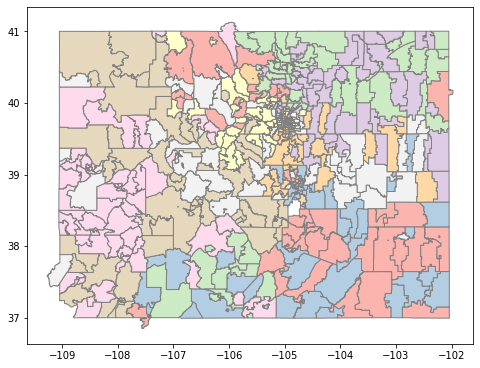

In [69]:
dft20_10 = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/zip_codes_2020-510/zip_codes_2020.shp")
ax2 = dft20_10.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

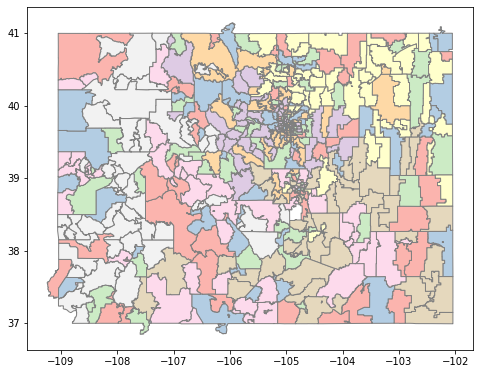

In [70]:
dft20_20 = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/zip_codes_2020/zip_codes_2020.shp")
ax2 = dft20_20.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

In [104]:
dft20_10['zip_code'].isna().sum()

0

In [105]:
print(dft20_10.shape)
print(dft20_20.shape)

(526, 156)
(528, 156)


In [72]:
z20_10 = dft20_10['zip_code'].values.tolist()
z20_20 = dft20_20['zip_code'].values.tolist()

In [73]:
print(dft20_10['zip_code'].nunique())
print(dft20_20['zip_code'].nunique())


526
520


In [74]:
print("20-10",set(z20_20)-set(z20_10))
print("10-20",set(z20_10)-set(z20_20))

20-10 {None}
10-20 {'80477', '80511', '81038', '80497', '80488', '81231'}


In [76]:
zboth = set(z20_20).intersection(set(z20_10))

In [77]:
len(zboth)

520

In [79]:
hA,hB = compareData(dft20_10,dft20_20,zboth,"zip_code")

ROH-ROH  80207 geometry
ROH-ROH  81233 geometry
ROH-ROH  81656 geometry
ROH-ROH  81325 geometry
ROH-ROH  81073 geometry
ROH-ROH  80455 geometry
ROH-ROH  80444 geometry
ROH-ROH  81047 geometry
ROH-ROH  81089 geometry
ROH-ROH  81084 geometry
ROH-ROH  80301 geometry
ROH-ROH  80902 geometry
ROH-ROH  80112 geometry
ROH-ROH  80219 geometry
ROH-ROH  80814 geometry


KeyboardInterrupt: 

In [114]:
dft20_10.columns

Index(['zip_code', 'pop', 'hispanic', 'white_nh', 'black_nh', 'ntvam_nh',
       'asian_nh', 'hawpi_nh', 'other_nh', 'twoplus_nh',
       ...
       'disabled', 'pop16_pls', 'laborforce', 'civ_lf', 'emp', 'unemp',
       'armedfrcs', 'not_lf', 'civ_ni_p', 'geometry'],
      dtype='object', length=156)

In [81]:
import random

In [ ]:
for col in zboth:
    row19 = dft20_10.loc[dft20_10["zip_code"] == col].to_dict()
    row20 = dft20_20.loc[dft20_20["zip_code"] == col].to_dict()
    
    vals19 = {}
    for key,val in row19.items():
        if key != 'geometry':
            value = list(val.values())
            vals19[key] = value[0]
            
    vals20 = {}
    for key,val in row20.items():
        if key != 'geometry':
            value = list(val.values())
            vals20[key] = value[0]
    
    for key,val19 in vals19.items():
        val20 = vals20[key]
        if val19 != val20:
                print("Diff ",col,key,val19,val20,val20-val19)
                
        if random.randint(1,10) == 3:
                print("C ",col,key,val19,val20)
        
    

In [82]:
random.randint(1,10)

3

In [59]:

for key,val in row19.items():
    vals19 = {}
    if key != 'the_geom':
        value = list(val.values())
        vals19[key] = value[0]

In [12]:
zips2022['pop'].max()

75525

In [13]:
zips2022['pop'].min()

0

In [6]:
for col in sorted(dft2021.columns):
    print(col)

age10_14
age15_19
age18_24
age20_24
age25_29
age30_34
age35_39
age40_44
age45_49
age50_54
age55_59
age5_9
age60_64
age65_69
age70_74
age75_79
age80_84
age85pl
ageless18
ageless5
armedfrcs
asian_nh
avghhsize
b1939_e
b1940_1949
b1950_1959
b1960_1969
b1970_1979
b1980_1989
b1990_1999
b2000_2009
bachl_hghr
bike
black_nh
blt_2010_p
born_in_co
brn_oth_st
car_all
car_alone
car_carpoo
citz_birth
citz_nat
civ_lf
civ_ni_p
civ_ni_pop
diff_state
disabled
emp
enrolled
familyhh
female
foreign_b
frm_abroad
geometry
gr_1_4
gr_5_8
gr_9_12
grad_prof
hawpi_nh
hhi100_125
hhi125_150
hhi150_200
hhi200_pl
hhi20_30
hhi30_40
hhi40_50
hhi50_60
hhi60_75
hhi75_100
hhi_l20k
hhldr_naln
hhldralone
hispanic
households
housing_un
hsgrad_sc
kndrgrtn
laborforce
male
med_age
med_c_rent
med_fam_in
med_g_rent
med_hh_inc
med_hm_val
med_yr_blt
n_enrolled
nohsdipl
nonfamhh
not_citz
not_lf
ntv_b_o_us
ntvam_nh
occ_hu
other_nh
own_occ_hu
owned
per_cap_in
pop
pop16_pls
pop25plus
pop_1p
pop_3pl
pov_65pl
pov_l18
preschool
ps_bel150


In [7]:
dft2022 = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/zip_codes_2022/zip_codes_2022.shp")
for col in sorted(dft2022.columns):
    print(col)

age10_14
age15_19
age18_24
age20_24
age25_29
age30_34
age35_39
age40_44
age45_49
age50_54
age55_59
age5_9
age60_64
age65_69
age70_74
age75_79
age80_84
age85pl
ageless18
ageless5
armedfrcs
asian_nh
avghhsize
b1939_e
b1940_1949
b1950_1959
b1960_1969
b1970_1979
b1980_1989
b1990_1999
b2000_2009
bachl_hghr
bike
black_nh
blt_2010_p
born_in_co
brn_oth_st
car_all
car_alone
car_carpoo
citz_birth
citz_nat
civ_lf
civ_ni_p
civ_ni_pop
diff_state
disabled
emp
enrolled
familyhh
female
foreign_b
frm_abroad
geometry
gr_1_4
gr_5_8
gr_9_12
grad_prof
hawpi_nh
hhi100_125
hhi125_150
hhi150_200
hhi200_pl
hhi20_30
hhi30_40
hhi40_50
hhi50_60
hhi60_75
hhi75_100
hhi_l20k
hhldr_naln
hhldralone
hispanic
households
housing_un
hsgrad_sc
kndrgrtn
laborforce
male
med_age
med_c_rent
med_fam_in
med_g_rent
med_hh_inc
med_hm_val
med_yr_blt
n_enrolled
nohsdipl
nonfamhh
not_citz
not_lf
ntv_b_o_us
ntvam_nh
occ_hu
other_nh
own_occ_hu
owned
per_cap_in
pop
pop16_pls
pop25plus
pop_1p
pop_3pl
pov_65pl
pov_l18
preschool
ps_bel150


### Counties

In [16]:
counties21 = pd.read_csv("Census_Counties_in_Colorado_2021_20240523.csv")
counties22 = pd.read_csv("Census_Counties_in_Colorado_2022_20240528.csv")

In [8]:
counties21.head()


,the_geom,geoname,geonum,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_
0,"MULTIPOLYGON (((-105.053289 39.856764, -105.05...",Adams,108001,514969,210869,248507,16630,2006,20103,685,1665,14504,261357,253612,34924,36694,40642,35730,32646,40331,42788,40991,36511,33337,30524,30476,25359,19816,14716,8873,5673,4938,135443,45193,34.2,176880,123255,53625,40004,13621,183772,176880,6892,120176,56704,334333,50604,195369,88360,78304,89241,33571,1989,1352.0,1470,360600,437523,29646,47800,265165,163862,8496,77446,508825,428441,36912,29883,11009,2580,265188,226323,198272,28051,7696,6105,1591,646,2992,2716,24815,240373,16890,53711,49717,57218,39345,23492,494540,131643,7441,6730,30599,32467,30851,17934,5621,362897,19422,39781,29527,22439,28344,17605,20198,3226,3230,120176,6452,3143,1700,3384,7762,13573,39719,22975,17016,2873,1579,56704,1402,1017,1528,4996,8423,11687,17190,9072,1389,510494,48959,86768,133796,53031,17602,4213,2.89,15380,10401,12965,13314,13606,18876,26892,20546,16683,15772,12445,511703,55788,395082,282806,282408,269511,12897,398,112276,511703
1,"MULTIPOLYGON (((-106.039348 37.458741, -106.03...",Alamosa,108003,16377,7793,7610,277,49,161,9,122,356,8270,8107,1013,1075,1197,1745,1533,1074,1192,1217,759,683,819,936,900,849,644,275,260,206,4019,2544,32.9,6327,3833,2494,2062,432,7009,6327,682,3500,2827,9814,1281,6017,2516,46217,55525,25249,1982,652.0,698,160400,15132,520,725,10025,4965,142,1245,16260,12967,981,1415,852,45,7179,6474,5720,754,18,17,1,13,337,32,305,6874,3067,1985,881,471,219,251,15937,5206,280,340,716,1074,934,1628,234,10731,584,1068,1138,917,1111,724,479,170,818,3500,476,404,723,747,284,250,377,93,76,32,38,2827,193,811,618,683,210,120,63,15,114,15402,2466,5041,4011,2175,600,222,2.43,1371,762,617,763,619,517,587,317,349,162,263,15937,2684,12914,7924,7924,7489,435,0,4990,15937
2,"MULTIPOLYGON (((-104.902671 39.685712, -104.89...",Arapahoe,108005,651621,129630,381106,69431,1912,40237,1421,1983,25901,324950,326671,38938,41935,44957,41029,38442,49944,51496,48301,47122,43861,40476,39903,39054,30874,24061,12898,8475,9855,152745,52556,37.0,247251,161271,85980,66564,19416,259291,247251,12040,160372,86879,446320,35396,212351,198573,84947,105584,45046,1985,1420.0,1556,415500,550134,48685,52802,261867,276454,11813,101487,644552,535671,45531,38078,21208,4064,346381,276353,248805,27548,11652,7199,4453,1204,4894,4422,47856,298525,24263,69286,75604,66771,40835,21766,628830,159814,10261,8059,32621,35297,37094,26377,10105,469016,21638,40276,36776,57844,59055,19716,16045,3344,4597,160372,2922,1616,2396,4720,9389,13074,40593,35285,34188,8062,8127,86879,2020,797,1681,4641,13433,

In [23]:
counties20 =  pd.read_csv("https://data.colorado.gov/resource/8j3i-rjn4.csv")

In [18]:
c20=counties20['geoname'].values.tolist()
c21=counties21['geoname'].values.tolist()
c22=counties22['geoname'].values.tolist()

In [21]:
print(counties20.shape)
print(counties21.shape)
print(counties22.shape)

(64, 157)
(64, 157)
(64, 157)


In [10]:
set(c20)-set(c21)

set()

In [11]:
set(c21)-set(c20)

set()

In [20]:
print("22-20",set(c22)-set(c20))
print("20-22",set(c20)-set(c22))

22-20 set()
20-22 set()


In [24]:
#  Compare 2020 with most recent data
hA,hB = compareData(counties20,counties22,c22,"geoname")

Adams v150k_200k 9355.0 1521 -7834.0 5.150558842866535
Alamosa hawpi_nh 59.0 6 -53.0 8.833333333333334
Archuleta tr_other 71.0 10 -61.0 6.1
Baca r1500t1999 9.0 1 -8.0 8.0
Bent ntv_b_o_us 39.0 5 -34.0 6.8
Bent walk 60.0 1 -59.0 59.0
Broomfield v250k_300k 1339.0 209 -1130.0 5.4066985645933014
Chaffee frm_abroad 270.0 12 -258.0 21.5
Chaffee v150k_200k 620.0 94 -526.0 5.595744680851064
Chaffee r400t599 337.0 45 -292.0 6.488888888888889
Cheyenne asian_nh 44.0 3 -41.0 13.666666666666666
Cheyenne diff_state 56.0 3 -53.0 17.666666666666668
Clear Creek tr_other 61.0 10 -51.0 5.1
Conejos asian_nh 13.0 2 -11.0 5.5
Costilla b1960_1969 165.0 16 -149.0 9.3125
Crowley r1500t1999 52.0 3 -49.0 16.333333333333332
Custer ntvam_nh 44.0 4 -40.0 10.0
Custer r400t599 95.0 2 -93.0 46.5
Dolores t_20_29 39.0 5 -34.0 6.8
Elbert frm_abroad 38.0 5 -33.0 6.6
Elbert rntl400 44.0 2 -42.0 21.0
Gilpin v150k_200k 80.0 5 -75.0 15.0
Gilpin v200k_250k 255.0 37 -218.0 5.891891891891892
Grand asian_nh 213.0 15 -198.0 13.2
Gu

In [26]:
targ = counties20.shape[0]
for col,cnt in sorted(hA.items()):
    if cnt/targ > .6: 
        print(col,cnt,targ)
        
        
targ = counties22.shape[0]
for col,cnt in sorted(hB.items()):
    if cnt/targ > .6: 
        print(col,cnt,targ)

pt_other 45 64
pt_other 41 64


<AxesSubplot:>

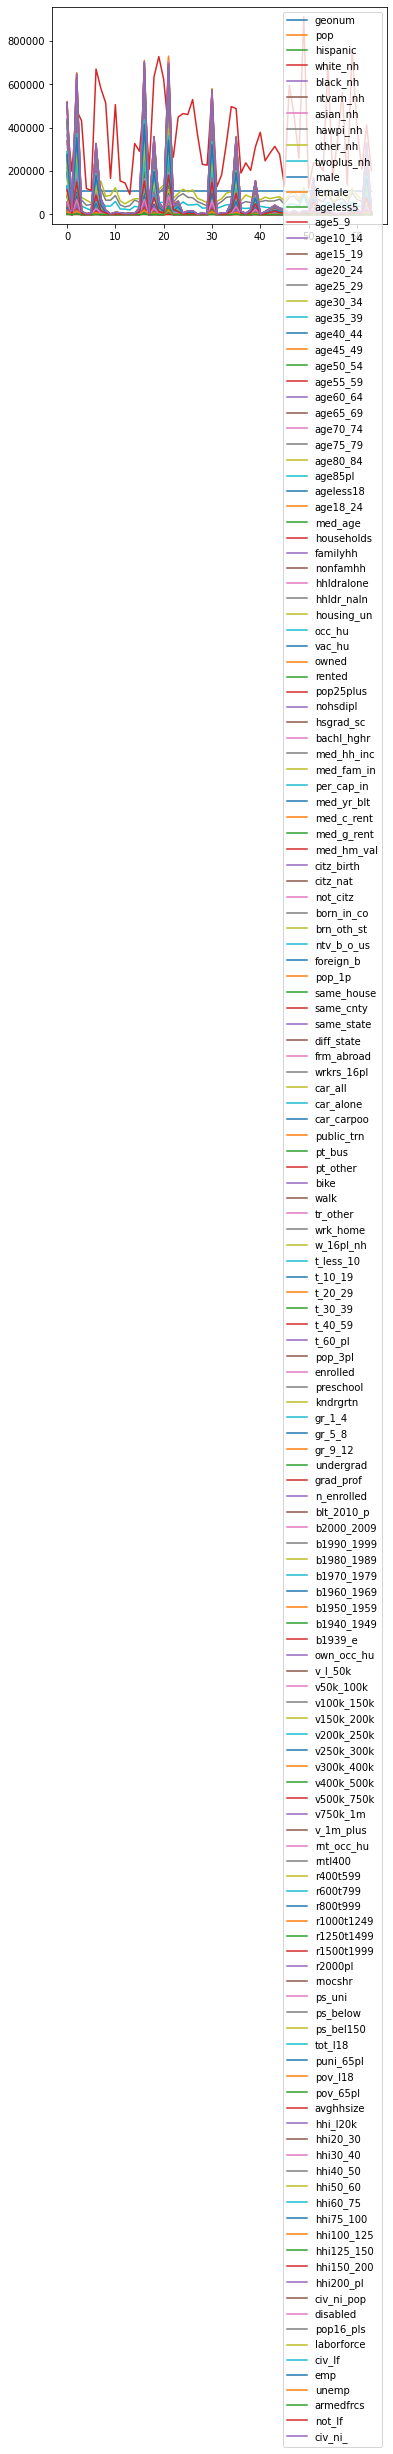

In [27]:
counties22.plot()

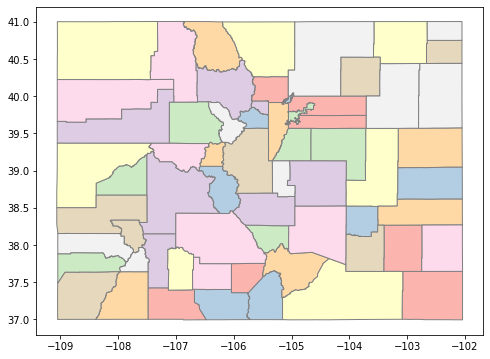

In [9]:
dft = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/counties_2022/census_counties.shp")
ax2 = dft.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

In [11]:
for col in sorted(dft.columns):
    print(col)

age10_14
age15_19
age18_24
age20_24
age25_29
age30_34
age35_39
age40_44
age45_49
age50_54
age55_59
age5_9
age60_64
age65_69
age70_74
age75_79
age80_84
age85pl
ageless18
ageless5
armedfrcs
asian_nh
avghhsize
b1939_e
b1940_1949
b1950_1959
b1960_1969
b1970_1979
b1980_1989
b1990_1999
b2000_2009
bachl_hghr
bike
black_nh
blt_2010_p
born_in_co
brn_oth_st
car_all
car_alone
car_carpoo
citz_birth
citz_nat
civ_lf
civ_ni_
civ_ni_pop
diff_state
disabled
emp
enrolled
familyhh
female
foreign_b
frm_abroad
geometry
geoname
geonum
gr_1_4
gr_5_8
gr_9_12
grad_prof
hawpi_nh
hhi100_125
hhi125_150
hhi150_200
hhi200_pl
hhi20_30
hhi30_40
hhi40_50
hhi50_60
hhi60_75
hhi75_100
hhi_l20k
hhldr_naln
hhldralone
hispanic
households
housing_un
hsgrad_sc
kndrgrtn
laborforce
male
med_age
med_c_rent
med_fam_in
med_g_rent
med_hh_inc
med_hm_val
med_yr_blt
n_enrolled
nohsdipl
nonfamhh
not_citz
not_lf
ntv_b_o_us
ntvam_nh
occ_hu
other_nh
own_occ_hu
owned
per_cap_in
pop
pop16_pls
pop25plus
pop_1p
pop_3pl
pov_65pl
pov_l18
presch

### Congressional Districts

In [2]:
#cg21 = pd.read_csv("Census_Congressional_Districts_in_Colorado_2021_20240523.csv")
cg22 = pd.read_csv("Census_Congressional_Districts_in_Colorado_2022_20240526.csv")

In [3]:
cg20 =  pd.read_csv("https://data.colorado.gov/resource/tbmm-ubn9.csv")

In [22]:
cg20.head()

,the_geom,con_dist,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_p
0,"MULTIPOLYGON (((-105.145973 39.577416, -105.14...",1,832187,227353,484664,64705,3576,28404,1005,1274,21206,416450,415737,50477,47541,43754,40966,49581,92994,89275,71245,58375,51566,46056,46046,44172,35401,25308,15790,10769,12871,166014,66305,35.1,353495,178813,174682,130175,44507,375882,353495,22387,185862,167633,599868,65073,240674,294121,70736,90883,44364,1971,1227,1316,390300,718696,44863,68628,339490,366167,13039,113491,822122,661964,65511,49894,39062,5691,464054,361890,327081,34809,28476,18730,9746,9315,19957,5630,38786,425268,33553,118201,103650,92494,53769,23601,800786,184190,13046,9744,37570,34659,31947,39570,17654,616596,31102,42372,29154,33215,59157,40372,54187,23137,63186,185862,2716,2552,5518,11720,16277,19591,38275,30996,35821,11732,10664,167633,10126,5010,9667,18604,31418,27446,38572,23319,3471,819344,98827,161464,164261,98049,27631,9766,2.31,45685,26007,27660,25749,27569,32746,45060,33422,23911,29638,36048,825417,79317,681894,491409,490841,472296,18545,568,190485,825417
1,"MULTIPOLYGON (((-109.060204 38.278238, -109.06...",3,744735,184347,524846,5649,10721,5697,608,894,11973,374529,370206,41065,45001,46924,48039,44599,47322,47651,48328,42472,44694,46550,53331,54535,48144,34223,23038,14702,14117,160827,64801,40.4,294418,187358,107060,84632,22428,373237,294418,78819,201161,93257,519107,49026,308784,161297,55616,70207,30845,1985,775,934,238200,699610,17655,27470,364440,327128,8042,45125,737863,623001,60972,27700,23814,2376,345165,291299,257930,33369,6775,6586,189,4537,13780,3818,24956,320209,68674,114646,54816,34772,24293,23008,721128,170094,10298,7520,37661,36738,38335,34071,5471,551034,14013,73951,71441,50661,64461,25023,24232,11449,38006,201161,12176,17070,22875,30021,24154,18885,27259,14625,18702,7458,7936,93257,7498,9149,16532,15438,15223,9709,9345,4464,5899,728879,103821,170231,158587,131541,29928,11866,2.47,48841,28990,29456,26655,23003,30025,39655,25690,14593,14489,13021,735836,104424,602289,373725,373309,352252,21057,416,228564,735836
2,"MULTIPOLYGON (((-106.599032 39.036273, -106.59...",5,798375,129814,566247,44540,3151,20042,2465,1879,30237,407894,390481,50898,51672,52075,52576,61406,63696,59325,53563,46618,47984,50190,52321,47134,39920,27847,17469,12767,10914,185859,82768,35.6,296383,201408,94975,75001,19974,326607,296383,30224,195185,101198,529748,31325,303321,195102,67043,80195,33085,1986,998,1152,272400,746610,28214,23551,260279,461703,24628,51765,788613,623096,85133,20385,52967,7032,383766,335056,295211,39845,2567,2315,252,1857,13016,3729,27541,356225,44686,116391,9361

In [4]:
print(cg20.shape)
print(cg22.shape)

(7, 156)
(7, 156)


In [5]:
A=cg20
B=cg22
cA=A['con_dist'].values.tolist()
cB=B['con_dist'].values.tolist()
print("20-22",set(cA)-set(cB))
print("22-20",set(cB)-set(cA))

20-22 set()
22-20 set()


In [33]:
c20

[1, 3, 5, 4, 7, 2, 6]

In [ ]:
A=cg20.copy()
B=cg22.copy()
C=cg20['con_dist'].values.tolist()
colT="con_dist"
for col in C:
    rowA = A.loc[A[colT] == col].to_dict()
    rowB = B.loc[B[colT] == col].to_dict()
   
    
    valsA = {}
    for key,val in rowA.items():
        if key != 'the_geom':
            value = list(val.values())
            valsA[key] = value[0]
            
    valsB = {}
    for key,val in rowB.items():
        if key != 'the_geom':
            value = list(val.values())
            valsB[key] = value[0]
    
    for key,valB in valsB.items():
       
        if key in valsA:
            valA = valsA[key]
            if valA != valB:
                diff = valB-valA
                if valB != 0:
                   p = abs(diff)/valB
                else:
                   p = -1
                if p > 1. or p == -1:
                    print(col,key,valA,valB,valB-valA,p)
        else:
            print("ROH-ROH ",col,key)

In [7]:
a = list(cg20.keys())
b = list(cg22.keys())

In [8]:
set(a)-set(b)

set()

In [9]:
set(b)-set(a)

set()

In [ ]:
for col in cg21.columns:
    print(col)

In [42]:
df = gpd.read_file("/home/joe/bic_etl/dola/census/data_source/tl_2021_us_cd116//tl_2021_us_cd116.shp")

In [43]:
 df.columns

Index(['STATEFP', 'CD116FP', 'GEOID', 'NAMELSAD', 'LSAD', 'CDSESSN', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')

In [44]:
df.shape

(444, 13)

In [48]:
df['FUNCSTAT'].value_counts()

N    441
F      3
Name: FUNCSTAT, dtype: int64

<AxesSubplot:>

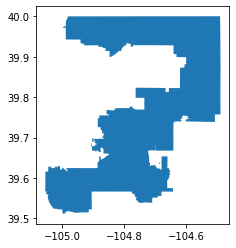

In [80]:
df.loc[df['GEOID'] == "0806"].plot()

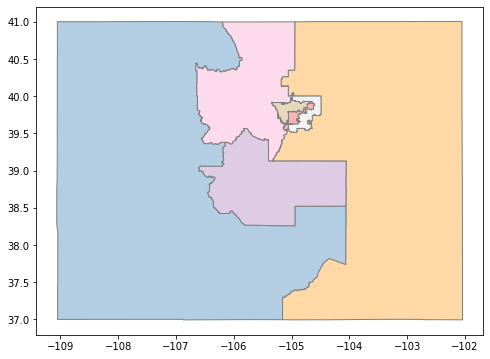

In [10]:
df = gpd.read_file("/home/joe/bic_etl/dola/census/data_source/temp/congressional_districts_2022/congressional_districts_2022.shp")
ax2 = df.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')
#df.loc[df['GEOID'] == "0806"].plot(edgecolor=u'gray', color='green', ax=ax2)

In [78]:
df['GEOID'].value_counts()

0806    1
0807    1
0804    1
0802    1
0801    1
0805    1
0803    1
Name: GEOID, dtype: int64

<AxesSubplot:>

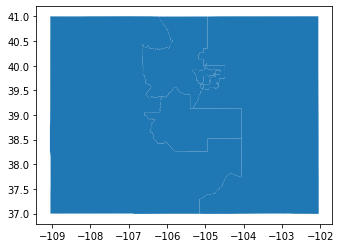

In [74]:
df.plot()

In [75]:
df['CD116FP'].value_counts()

04    1
06    1
02    1
03    1
07    1
01    1
05    1
Name: CD116FP, dtype: int64

In [52]:
df.shape

(7, 13)

In [53]:
df['FUNCSTAT'].value_counts()

N    7
Name: FUNCSTAT, dtype: int64

In [54]:
dfc = pd.read_csv("/home/joe/bic_etl/dola/census/data_source/temp/congressional_districts_2020.csv")

In [55]:
dfc.head()

,con_dist,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400T599,r600T799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_p
0,2,817394,88564,668154,7066,3237,26300,498,1517,22058,413343,404051,37537,41978,47690,57171,75076,62826,55192,53009,50591,52907,50105,56351,52958,46073,33545,20245,10463,13677,155510,103942,38.0,317900,194743,123157,83873,39284,377645,317900,59745,217489,100411,557942,18502,226432,313008,86011,110136,46428,1987,1383,1486,463500,759113,27334,30947,292971,454975,11167,58281,810953,651782,72715,42980,38143,5333,437509,326319,297593,28726,13887,13179,708,12101,15891,4900,64411,373098,51476,120931,76885,54213,41558,28035,795815,219851,11641,7778,33835,36888,38286,74061,17362,575964,20763,13397,60323,78646,59434,75813,29203,14648,5256,217489,6281,2645,2114,4957,9816,13682,44018,39748,53798,22427,10738,100411,2235,2526,5563,7686,15486,16006,28380,11393,4156,795483,78264,116603,153600,122136,10522,7257,2.50,31503,20019,19356,19731,20372,28130,42074,35966,23797,33993,42959,812040,69946,680913,466769,466236,444758,21478,533,214144,812040
1,4,837275,187299,593373,11201,3185,19856,1108,1583,19670,424313,412962,53041,57798,60151,59002,49362,53900,57235,57914,57468,56539,53842,55528,49925,40944,30563,19072,12200,12791,207319,72035,37.4,294488,210531,83957,67559,16398,313611,294488,19123,216972,77516,557921,49882,306587,201452,79205,95366,37949,1992,1076,1220,364100,769370,27173,40732,402082,356859,10429,67905,828285,694866,56100,47529,26697,3093,413609,353697,315711,37986,3748,2518,1230,1123,8253,3933,42855,370754,58949,97294,66705,62291,51670,33845,807042,213920,14713,10838,47133,46889,48929,36330,9088,593122,23872,11086,74400,58926,30935,43378,17703,15432,7508,216972,9549,10934,10191,12005,16675,20286,45020,36604,39043,10484,3891,77516,4319,4699,7599,10135,10819,10217,16248,5350,1713,818025,70008,125098,204001,113070,19614,8598,2.78,29930,20007,21421,19687,20015,28335,40326,33519,24026,27115,30107,824504,87300,654019,440285,439413,420218,19195,872,213734,824504
2,6,825402,167560,493690,76490,3001,52938,1651,2670,27402,410844,414558,50522,57072,61135,53444,47962,59768,61108,58478,61951,59675,52871,54050,44885,37418,27092,16225,9926,11820,204641,65494,36.9,292875,203103,89772,70056,19716,304472,292875,11597,198824,94051,555267,43536,272084,239647,86388,103271,41668,1988,1366,1489,402800,700697,57465,67240,340177,347345,13175,124705,816628,682651,56689,45209,26129,5950,432313,359800,322796,37004,14793,8180,6613,1203,5725,4622,46170,386143,30048,89044,94070,84137,56842,32002,796157,212245,13319,11359,44918,47617,49396,33968,11668,583912,14141,9891,59332,57598,64278,60493,19506,13370,2606,198824,3516,2169,3372,7585,13652,19

In [58]:
print(dfc.columns)

Index(['con_dist', 'pop', 'hispanic', 'white_nh', 'black_nh', 'ntvam_nh',
       'asian_nh', 'hawpi_nh', 'other_nh', 'twoplus_nh',
       ...
       'civ_ni_pop', 'disabled', 'pop16_pls', 'laborforce', 'civ_lf', 'emp',
       'unemp', 'armedfrcs', 'not_lf', 'civ_ni_p'],
      dtype='object', length=155)


In [ ]:
for col in sorted(dfc.columns):
    print(col)

In [60]:
dfc['r400T599'].value_counts()

2526    1
4699    1
1656    1
8039    1
823     1
4235    1
3090    1
Name: r400T599, dtype: int64

In [61]:
dfc['r600T799'].value_counts()

15695    1
7599     1
5563     1
2248     1
10340    1
3618     1
6128     1
Name: r600T799, dtype: int64

In [13]:
dft = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/congressional_districts_2022/congressional_districts_2022.shp")
for col in sorted(dft.columns):
    print(col)

age10_14
age15_19
age18_24
age20_24
age25_29
age30_34
age35_39
age40_44
age45_49
age50_54
age55_59
age5_9
age60_64
age65_69
age70_74
age75_79
age80_84
age85pl
ageless18
ageless5
armedfrcs
asian_nh
avghhsize
b1939_e
b1940_1949
b1950_1959
b1960_1969
b1970_1979
b1980_1989
b1990_1999
b2000_2009
bachl_hghr
bike
black_nh
blt_2010_p
born_in_co
brn_oth_st
car_all
car_alone
car_carpoo
citz_birth
citz_nat
civ_lf
civ_ni_p
civ_ni_pop
con_dist
diff_state
disabled
emp
enrolled
familyhh
female
foreign_b
frm_abroad
geometry
gr_1_4
gr_5_8
gr_9_12
grad_prof
hawpi_nh
hhi100_125
hhi125_150
hhi150_200
hhi200_pl
hhi20_30
hhi30_40
hhi40_50
hhi50_60
hhi60_75
hhi75_100
hhi_l20k
hhldr_naln
hhldralone
hispanic
households
housing_un
hsgrad_sc
kndrgrtn
laborforce
male
med_age
med_c_rent
med_fam_in
med_g_rent
med_hh_inc
med_hm_val
med_yr_blt
n_enrolled
nohsdipl
nonfamhh
not_citz
not_lf
ntv_b_o_us
ntvam_nh
occ_hu
other_nh
own_occ_hu
owned
per_cap_in
pop
pop16_pls
pop25plus
pop_1p
pop_3pl
pov_65pl
pov_l18
preschool
p

### Tracts

In [30]:
tracts21 = pd.read_csv("Census_Tracts_in_Colorado_2021_20240523.csv")
tracts22 = pd.read_csv("Census_Tracts_in_Colorado_2022_20240528.csv")

In [31]:
tracts19 =  pd.read_csv("https://data.colorado.gov/resource/cj4m-96y8.csv?$limit=10000")

In [32]:

tracts20 =  pd.read_csv("https://data.colorado.gov/resource/7t53-5gfx.csv?$limit=10000")

In [33]:
print(tracts19.shape)
print(tracts20.shape)
print(tracts21.shape)
print(tracts22.shape)

(1249, 157)
(1447, 157)
(1447, 157)
(1447, 157)


In [93]:
tracts20.head()

,the_geom,geoname,geonum,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_
0,"MULTIPOLYGON (((-105.77139100000001 37.045725,...",9727.00,108023972700,1684.0,1378.0,237.0,14.0,0.0,0.0,0.0,0.0,55.0,908.0,776.0,61.0,65.0,82.0,62.0,54.0,137.0,83.0,119.0,23.0,93.0,90.0,108.0,180.0,199.0,94.0,135.0,56.0,43.0,251.0,73.0,54.2,892.0,459.0,433.0,417.0,16.0,1489.0,892.0,597.0,545.0,347.0,1360.0,290.0,872.0,198.0,25000.0,33859.0,20584.0,1961.0,274.0,347.0,105200.0,1574.0,9.0,101.0,1199.0,375.0,0.0,110.0,1677.0,1512.0,71.0,20.0,60.0,14.0,600.0,546.0,361.0,185.0,0.0,0.0,0.0,0.0,32.0,0.0,22.0,578.0,189.0,88.0,70.0,32.0,172.0,27.0,1642.0,253.0,19.0,0.0,65.0,69.0,56.0,44.0,0.0,1389.0,7.0,62.0,221.0,109.0,230.0,127.0,97.0,93.0,543.0,545.0,114.0,131.0,132.0,60.0,48.0,11.0,18.0,0.0,0.0,10.0,21.0,347.0,124.0,43.0,23.0,19.0,0.0,21.0,0.0,0.0,117.0,1684.0,517.0,840.0,251.0,527.0,135.0,130.0,1.89,349.0,172.0,142.0,48.0,45.0,33.0,47.0,28.0,4.0,18.0,6.0,1684.0,592.0,1446.0,693.0,693.0,631.0,62.0,0.0,753.0,1684.0
1,MULTIPOLYGON (((-105.017385 39.740514999999995...,19.01,108031001901,3346.0,1519.0,998.0,697.0,26.0,59.0,0.0,0.0,47.0,1689.0,1657.0,281.0,281.0,273.0,75.0,380.0,272.0,506.0,224.0,217.0,165.0,180.0,139.0,103.0,82.0,14.0,99.0,16.0,39.0,835.0,455.0,30.9,1238.0,563.0,675.0,504.0,171.0,1290.0,1238.0,52.0,335.0,903.0,2056.0,568.0,849.0,639.0,31266.0,35179.0,24300.0,1966.0,853.0,877.0,347000.0,2548.0,229.0,569.0,1334.0,1208.0,6.0,798.0,3288.0,2666.0,364.0,82.0,162.0,14.0,1435.0,813.0,715.0,98.0,306.0,133.0,173.0,7.0,96.0,62.0,151.0,1284.0,252.0,380.0,102.0,336.0,127.0,87.0,3238.0,854.0,138.0,12.0,317.0,126.0,59.0,160.0,42.0,2384.0,456.0,45.0,70.0,41.0,8.0,71.0,74.0,0.0,525.0,335.0,0.0,0.0,14.0,22.0,61.0,39.0,67.0,55.0,63.0,0.0,14.0,903.0,266.0,83.0,53.0,113.0,36.0,201.0,101.0,36.0,14.0,3333.0,1407.0,1615.0,822.0,250.0,531.0,102.0,2.51,432.0,147.0,130.0,15.0,54.0,144.0,73.0,67.0,36.0,68.0,72.0,3346.0,443.0,2511.0,1758.0,1758.0,1442.0,316.0,0.0,753.0,3346.0
2,MULTIPOLYGON (((-104.71986800000002 38.8737549...,51.08,108041005108,9219.0,1537.0,6796.0,301.0,0.0,164.0,0.0,0.0,421.0,4869.0,4350.0,924.0,607.0,565.0,366.0,588.0,975.0,929.0,627.0,627.0,537.0,582.0,649.0,487.0,313.0,213.0,156.0,74.0,0.0,2391.0,659.0,33.2,3312.0,2527.0,785.0,576.0,209.0,3430.0,3312.0,118.0,2365.0,947.0,6169.0,102.0,3490.0,2577.0,89467.0,97537.0,36105.0,1996.0,1303.0,1517.0,244700.0,8901.0,229.0,89.0,3190.0,5432.0,279.0,318.0,9032.0,6639.0,1353.0,142.0,877.0,21.0,5241.0,4768.0,4102.0,666.0,17.0,17.0,0.0,0.0,0.0,27.0,429.0,4812.0,252.0,1134.0,1982.0,1052.0,209.0,183.0,8813.0,2334.0,141.0,202.0,458.0,371.0,351.0,556.0,255.0

In [100]:
tracts21.head()

,the_geom,geoname,geonum,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_
0,"MULTIPOLYGON (((-104.990382 39.911543, -104.98...",85.06,108001008506,6249,1874,3439,98,81,83,102,22,550,3183,3066,350,485,666,358,590,824,463,771,249,313,257,159,159,67,113,134,103,188,1644,805,28.3,2745,1340,1405,986,419,2828,2745,83,355,2390,3800,516,2426,858,43804.0,46920.0,29839.0,1979.0,1279.0,1332.0,303700.0,5526,142,581,3057,2469,0,723,6176,4401,1200,341,203,31,3230,2797,2622,175,174,174,0,0,114,20,125,3105,311,731,423,754,367,519,5969,1449,36,119,320,637,135,165,37,4520,293,236,439,344,1304,124,33,22,33,355,0,32,33,13,32,63,121,45,16,0,0,2390,136,157,17,247,401,696,629,90,17,6120,543,1439,1644,483,139,99,2.23,301,405,547,313,291,210,213,217,104,87,57,6120,905,4721,3394,3394,3253,141,0,1327,6120
1,"MULTIPOLYGON (((-104.912496 39.874403, -104.91...",85.35,108001008535,4626,1756,2613,108,23,87,0,0,39,2500,2126,261,145,495,243,363,492,359,327,382,549,275,166,157,225,102,25,60,0,1044,463,34.2,1529,1180,349,263,86,1539,1529,10,1058,471,3119,681,1777,661,100662.0,110469.0,33100.0,2005.0,1478.0,1618.0,352400.0,4010,342,274,2793,1189,28,616,4552,3718,286,336,212,0,2766,2373,2164,209,0,0,0,0,14,0,379,2387,97,497,401,553,402,437,4471,986,77,11,126,455,165,44,108,3485,252,1017,74,36,28,4,85,36,7,1058,49,0,0,0,36,114,630,121,108,0,0,471,47,0,7,0,0,134,180,93,10,4626,335,512,1044,412,101,20,3.03,99,35,25,25,74,199,303,379,168,200,22,4614,397,3693,2904,2892,2811,81,12,789,4614
2,"MULTIPOLYGON (((-104.965973 39.930253, -104.96...",85.45,108001008545,6265,875,4940,11,0,129,0,18,292,3112,3153,353,423,552,445,193,343,408,524,321,497,569,388,398,449,245,113,44,0,1663,303,38.7,2131,1682,449,305,144,2176,2131,45,1923,208,4299,199,2030,2070,120612.0,127500.0,42618.0,1993.0,1755.0,1877.0,412700.0,6089,155,21,3072,2944,73,176,6230,5670,179,244,137,0,3241,2702,2465,237,46,46,0,0,2,27,464,2777,277,498,632,642,438,290,6076,1601,180,41,313,478,395,142,52,4475,68,258,1172,306,340,18,14,0,0,1923,34,0,0,13,62,76,702,585,370,68,13,208,0,0,0,17,29,0,69,81,12,6179,179,500,1577,851,41,39,2.94,75,68,128,110,53,104,282,293,429,291,298,6265,373,4827,3444,3444,3333,111,0,1383,6265
3,"MULTIPOLYGON (((-104.91545 39.827225, -104.906...",87.06,108001008706,5882,3889,1472,499,1,0,0,0,21,2688,3194,259,434,808,452,391,263,554,425,510,352,297,266,257,118,247,169,31,49,1834,510,33.3,1891,1356,535,439,96,1998,1891,107,1017,874,3538,919,2318,301,47098.0,52373.0,19617.0,1957.0,951.0,1114.0,269500.0,4870,317,695,3679,1062,129,1012,5864,4876,622,255,106,5,2684,2398,1829,569,111,24,87,0,0,0,175,2509,209,688,567,636,236,173,5741,1882,46,

In [36]:
col='geonum'
t19=tracts19[col].values.tolist()
t20=tracts20[col].values.tolist()
t21=tracts21[col].values.tolist()
t22=tracts22[col].values.tolist()

print("20-21",set(t20)-set(t21))
print("21-20",set(t21)-set(t20))
print("22-20",set(t22)-set(t20))
#print("22-19",set(t22)-set(t19))

20-21 set()
21-20 set()
22-20 set()


In [ ]:
hA,hB = compareData(tracts20,tracts22,t22,"geonum")

In [39]:
for col,val in sorted(histA.items()):
    print(col,val)

age10_14 50
age15_19 25
age18_24 16
age20_24 22
age25_29 19
age30_34 17
age35_39 20
age40_44 23
age45_49 25
age50_54 21
age55_59 21
age5_9 50
age60_64 20
age65_69 33
age70_74 45
age75_79 82
age80_84 187
age85pl 215
ageless18 24
ageless5 51
armedfrcs 1094
asian_nh 254
b1939_e 418
b1940_1949 635
b1950_1959 365
b1960_1969 214
b1970_1979 86
b1980_1989 69
b1990_1999 56
b2000_2009 91
bachl_hghr 11
bike 820
black_nh 321
blt_2010_p 286
born_in_co 11
brn_oth_st 9
car_all 15
car_alone 15
car_carpoo 41
citz_birth 9
citz_nat 49
civ_lf 14
civ_ni_ 13
civ_ni_pop 13
diff_state 65
disabled 15
emp 14
enrolled 13
familyhh 19
female 11
foreign_b 20
frm_abroad 728
gr_1_4 59
gr_5_8 60
gr_9_12 48
grad_prof 181
hawpi_nh 1223
hhi100_125 30
hhi125_150 49
hhi150_200 69
hhi200_pl 108
hhi20_30 64
hhi30_40 55
hhi40_50 44
hhi50_60 41
hhi60_75 25
hhi75_100 26
hhi_l20k 43
hhldr_naln 46
hhldralone 21
hispanic 14
households 15
housing_un 15
hsgrad_sc 11
kndrgrtn 223
laborforce 14
male 9
med_yr_blt 45
n_enrolled 10
nohsd

In [40]:
for col,val in sorted(histB.items()):
    print(col,val)

age10_14 47
age15_19 31
age18_24 20
age20_24 24
age25_29 19
age30_34 17
age35_39 15
age40_44 20
age45_49 19
age50_54 24
age55_59 21
age5_9 47
age60_64 17
age65_69 23
age70_74 37
age75_79 66
age80_84 145
age85pl 194
ageless18 25
ageless5 54
armedfrcs 1057
asian_nh 242
b1939_e 447
b1940_1949 667
b1950_1959 351
b1960_1969 218
b1970_1979 88
b1980_1989 71
b1990_1999 65
b2000_2009 78
bachl_hghr 14
bike 849
black_nh 341
blt_2010_p 167
born_in_co 10
brn_oth_st 10
car_all 16
car_alone 16
car_carpoo 44
citz_birth 10
citz_nat 39
civ_lf 15
civ_ni_ 14
civ_ni_pop 14
diff_state 56
disabled 15
emp 15
enrolled 12
familyhh 19
female 12
foreign_b 21
frm_abroad 740
gr_1_4 61
gr_5_8 53
gr_9_12 44
grad_prof 166
hawpi_nh 1227
hhi100_125 25
hhi125_150 41
hhi150_200 43
hhi200_pl 59
hhi20_30 85
hhi30_40 54
hhi40_50 57
hhi50_60 45
hhi60_75 29
hhi75_100 21
hhi_l20k 49
hhldr_naln 44
hhldralone 20
hispanic 14
households 16
housing_un 16
hsgrad_sc 11
kndrgrtn 218
laborforce 15
male 10
n_enrolled 10
nohsdipl 55
nonfa

In [41]:
df = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/tracts_2022/census_tracts.shp")

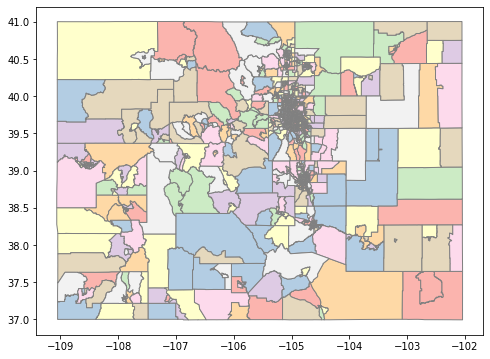

In [42]:
ax2 = df.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')


### Block Groups

In [43]:
block21=pd.read_csv("Census_Block_Groups_in_Colorado_2021_20240524.csv")
block22=pd.read_csv("Census_Block_Groups_in_Colorado_2022_20240528.csv")

In [44]:
block20 =  pd.read_csv("https://data.colorado.gov/resource/jwbw-xb7i.csv?$limit=10000")

In [45]:
print(block20.shape)
print(block21.shape)
print(block22.shape)

(4058, 157)
(4058, 157)
(4058, 157)


In [5]:
block20.head()

,the_geom,geoname,geonum,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_
0,"MULTIPOLYGON (((-107.140707 37.75, -107.13994 ...",1,1080799736001,853.0,34.0,703.0,10.0,1.0,47.0,0.0,0.0,58.0,398.0,455.0,18.0,46.0,41.0,28.0,20.0,77.0,73.0,16.0,78.0,18.0,83.0,109.0,74.0,62.0,42.0,38.0,18.0,12.0,129.0,24.0,51.0,394.0,252.0,142.0,132.0,10.0,1370.0,394.0,976.0,288.0,106.0,700.0,14.0,307.0,379.0,53571.0,65000.0,30908.0,1988.0,750.0,750.0,329300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,326.0,243.0,250.0,118.0,103.0,27.0,21.0,209.0,288.0,11.0,10.0,9.0,26.0,21.0,43.0,82.0,36.0,37.0,10.0,3.0,106.0,5.0,0.0,59.0,0.0,0.0,27.0,0.0,3.0,12.0,853.0,127.0,149.0,NaN,NaN,NaN,NaN,2.13,48.0,15.0,16.0,104.0,38.0,47.0,40.0,44.0,18.0,14.0,10.0,NaN,NaN,741.0,489.0,482.0,455.0,27.0,7.0,252.0,NaN
1,"MULTIPOLYGON (((-104.973785 39.844295, -104.97...",2,1080010090032,619.0,271.0,348.0,0.0,0.0,0.0,0.0,0.0,0.0,307.0,312.0,24.0,0.0,13.0,89.0,38.0,16.0,58.0,35.0,20.0,26.0,32.0,116.0,89.0,10.0,33.0,8.0,12.0,0.0,37.0,127.0,49.6,223.0,161.0,62.0,12.0,50.0,636.0,636.0,0.0,479.0,157.0,455.0,49.0,360.0,46.0,56641.0,49183.0,25084.0,1974.0,NaN,NaN,236600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,211.0,12.0,48.0,0.0,0.0,197.0,12.0,0.0,0.0,25.0,84.0,12.0,48.0,16.0,0.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,0.0,0.0,619.0,183.0,183.0,NaN,NaN,NaN,NaN,2.78,38.0,0.0,10.0,53.0,16.0,48.0,20.0,15.0,14.0,0.0,9.0,NaN,NaN,582.0,386.0,386.0,350.0,36.0,0.0,196.0,NaN
2,"MULTIPOLYGON (((-104.996632 39.903307, -104.98...",2,1080010093232,689.0,312.0,292.0,35.0,4.0,0.0,0.0,0.0,46.0,339.0,350.0,98.0,71.0,68.0,28.0,75.0,119.0,22.0,81.0,16.0,22.0,31.0,0.0,19.0,9.0,29.0,1.0,0.0,0.0,258.0,82.0,25.1,258.0,135.0,123.0,77.0,46.0,353.0,353.0,0.0,239.0,114.0,349.0,30.0,287.0,32.0,54722.0,44453.0,19851.0,1978.0,1073.0,1177.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0,9.0,31.0,54.0,100.0,10.0,35.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,258.0,0.0,0.0,0.0,54.0,106.0,68.0,30.0,0.0,0.0,667.0,66.0,312.0,NaN,NaN,NaN,NaN,2.67,22.0,39.0,12.0,25.0,64.0,47.0,49.0,0.0,0.0,0.0,0.0,NaN,NaN,441.0,352.0,352.0,352.0,0.0,0.0,89.0,NaN
3,"MULTIPOLYGON (((-105.053036 39.892187, -105.05...",2,1080010094092,1794.0,126.0,1658.0,0.0,0.0,10.0,0.0,0.0,0.0

In [6]:
block20['geonum'].nunique()

4058

In [46]:
b20 = block20['geonum'].values.tolist()
b21 = block21['geonum'].values.tolist()
b22 = block22['geonum'].values.tolist()

In [47]:
print("20-21",set(b20)-set(b21))
print("21-20",set(b21)-set(b20))
print("22-20",set(b22)-set(b20))

20-21 set()
21-20 set()
22-20 set()


In [ ]:
hA,hB = compareData(block20,block22,b22,"geonum")

In [49]:
for col,cnt in sorted(histA.items()):
    print(col,cnt)

age10_14 50
age15_19 25
age18_24 16
age20_24 22
age25_29 19
age30_34 17
age35_39 20
age40_44 23
age45_49 25
age50_54 21
age55_59 21
age5_9 50
age60_64 20
age65_69 33
age70_74 45
age75_79 82
age80_84 187
age85pl 215
ageless18 24
ageless5 51
armedfrcs 1094
asian_nh 254
b1939_e 418
b1940_1949 635
b1950_1959 365
b1960_1969 214
b1970_1979 86
b1980_1989 69
b1990_1999 56
b2000_2009 91
bachl_hghr 11
bike 820
black_nh 321
blt_2010_p 286
born_in_co 11
brn_oth_st 9
car_all 15
car_alone 15
car_carpoo 41
citz_birth 9
citz_nat 49
civ_lf 14
civ_ni_ 13
civ_ni_pop 13
diff_state 65
disabled 15
emp 14
enrolled 13
familyhh 19
female 11
foreign_b 20
frm_abroad 728
gr_1_4 59
gr_5_8 60
gr_9_12 48
grad_prof 181
hawpi_nh 1223
hhi100_125 30
hhi125_150 49
hhi150_200 69
hhi200_pl 108
hhi20_30 64
hhi30_40 55
hhi40_50 44
hhi50_60 41
hhi60_75 25
hhi75_100 26
hhi_l20k 43
hhldr_naln 46
hhldralone 21
hispanic 14
households 15
housing_un 15
hsgrad_sc 11
kndrgrtn 223
laborforce 14
male 9
med_yr_blt 45
n_enrolled 10
nohsd

In [50]:
for col,cnt in sorted(histB.items()):
    print(col,cnt)

age10_14 47
age15_19 31
age18_24 20
age20_24 24
age25_29 19
age30_34 17
age35_39 15
age40_44 20
age45_49 19
age50_54 24
age55_59 21
age5_9 47
age60_64 17
age65_69 23
age70_74 37
age75_79 66
age80_84 145
age85pl 194
ageless18 25
ageless5 54
armedfrcs 1057
asian_nh 242
b1939_e 447
b1940_1949 667
b1950_1959 351
b1960_1969 218
b1970_1979 88
b1980_1989 71
b1990_1999 65
b2000_2009 78
bachl_hghr 14
bike 849
black_nh 341
blt_2010_p 167
born_in_co 10
brn_oth_st 10
car_all 16
car_alone 16
car_carpoo 44
citz_birth 10
citz_nat 39
civ_lf 15
civ_ni_ 14
civ_ni_pop 14
diff_state 56
disabled 15
emp 15
enrolled 12
familyhh 19
female 12
foreign_b 21
frm_abroad 740
gr_1_4 61
gr_5_8 53
gr_9_12 44
grad_prof 166
hawpi_nh 1227
hhi100_125 25
hhi125_150 41
hhi150_200 43
hhi200_pl 59
hhi20_30 85
hhi30_40 54
hhi40_50 57
hhi50_60 45
hhi60_75 29
hhi75_100 21
hhi_l20k 49
hhldr_naln 44
hhldralone 20
hispanic 14
households 16
housing_un 16
hsgrad_sc 11
kndrgrtn 218
laborforce 15
male 10
n_enrolled 10
nohsdipl 55
nonfa

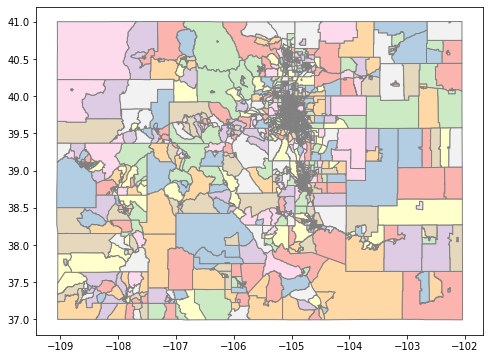

In [51]:
df = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/block_groups_2022/census_block_groups.shp")
ax2 = df.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')


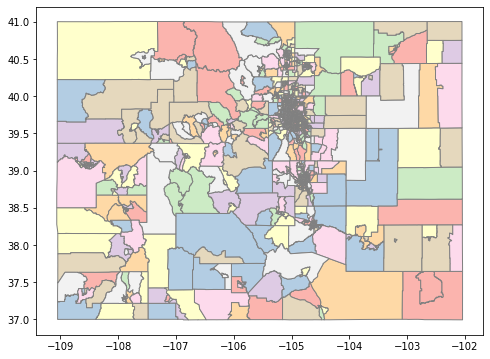

In [16]:
dft = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/tracts_2021/census_tracts.shp")
ax2 = dft.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')


### Places

In [52]:
places21 = pd.read_csv("Census_Places_in_Colorado_2021_20240524.csv")
places22 = pd.read_csv("Census_Places_in_Colorado_2022_20240528.csv")

In [53]:
places20 =  pd.read_csv("https://data.colorado.gov/resource/33q3-djk8.csv?$limit=10000")

In [54]:
print(places20.shape)
print(places21.shape)
print(places22.shape)

(482, 157)
(482, 157)
(482, 157)


In [22]:
places20.head()

,the_geom,geoname,geonum,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_
0,"MULTIPOLYGON (((-104.904764 39.558238, -104.90...",Acres Green,10800320,2888.0,113.0,2299.0,40.0,0.0,278.0,0.0,0.0,158.0,1397.0,1491.0,178.0,133.0,167.0,209.0,199.0,187.0,150.0,145.0,384.0,184.0,210.0,174.0,180.0,196.0,102.0,53.0,26.0,11.0,626.0,260.0,40.8,1016.0,852.0,164.0,123.0,41.0,1051.0,1016.0,35.0,836.0,180.0,2002.0,24.0,1129.0,849.0,102000.0,109231.0,37521.0,NaN,2195.0,2275.0,378300.0,2603.0,94.0,191.0,1223.0,1366.0,14.0,285.0,2873.0,2508.0,42.0,207.0,88.0,28.0,1816.0,1367.0,1298.0,69.0,59.0,9.0,50.0,0.0,26.0,25.0,339.0,1477.0,250.0,551.0,266.0,157.0,120.0,133.0,2809.0,678.0,43.0,25.0,104.0,109.0,196.0,170.0,31.0,2131.0,0.0,0.0,6.0,65.0,948.0,12.0,20.0,0.0,0.0,836.0,30.0,0.0,0.0,1.0,19.0,18.0,447.0,276.0,45.0,0.0,0.0,180.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,149.0,13.0,2888.0,135.0,153.0,626.0,388.0,9.0,36.0,2.84,77.0,27.0,38.0,8.0,67.0,65.0,210.0,252.0,98.0,118.0,56.0,2888.0,202.0,2379.0,1853.0,1853.0,1834.0,19.0,0.0,526.0,2888.0
1,"MULTIPOLYGON (((-104.678262 39.738731, -104.67...",Aetna Estates,10800620,1231.0,631.0,569.0,21.0,0.0,0.0,0.0,10.0,0.0,561.0,670.0,74.0,101.0,176.0,32.0,118.0,7.0,263.0,33.0,202.0,38.0,78.0,26.0,37.0,15.0,20.0,11.0,0.0,0.0,362.0,139.0,33.6,406.0,364.0,42.0,31.0,11.0,437.0,406.0,31.0,181.0,225.0,730.0,81.0,604.0,45.0,53832.0,53995.0,17346.0,1988.0,1105.0,1348.0,48300.0,922.0,120.0,189.0,526.0,285.0,111.0,309.0,1231.0,1151.0,0.0,80.0,0.0,0.0,577.0,550.0,550.0,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,577.0,11.0,233.0,59.0,89.0,151.0,34.0,1188.0,298.0,7.0,0.0,79.0,171.0,20.0,21.0,0.0,890.0,15.0,26.0,170.0,48.0,39.0,32.0,107.0,0.0,0.0,181.0,102.0,79.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,225.0,0.0,0.0,0.0,11.0,61.0,103.0,32.0,18.0,0.0,1231.0,127.0,297.0,362.0,46.0,54.0,0.0,3.03,59.0,21.0,11.0,55.0,124.0,97.0,39.0,0.0,0.0,0.0,0.0,1231.0,65.0,880.0,632.0,632.0,577.0,55.0,0.0,248.0,1231.0
2,"MULTIPOLYGON (((-104.662605 37.403139, -104.66...",Aguilar,10800760,492.0,306.0,177.0,0.0,0.0,0.0,0.0,0.0,9.0,165.0,327.0,20.0,6.0,6.0,24.0,51.0,2.0,0.0,8.0,35.0,13.0,61.0,33.0,54.0,12.0,34.0,13.0,114.0,6.0,42.0,65.0,58.0,318.0,119.0,199.0,192.0,7.0,404.0,318.0,86.0,271.0,47.0,385.0,132.0,212.0,41.0,24810.0,32321.0,26136.0,1973.0,143.0,368.0,75700.0,483.0,9.0,0.0,359.0,115.0,9.0,9.0,492.0,440.0,27.0,15.0,10.0,0.0,272.0,245.0,68.0,177.0,0.0,0.0,0.0,0.0,10.0,0.0,17.0,255.0,38.0,105.0,48.0,64.0,0.0,0.0,479.0,32.0,6.0,0.0,0.0,6.0,13.0,7.0,0.0,447.0,0.0,17.0,37.0,39.0,161.0,7.0,0.0,12.0,131.0,271.0,29.0,178.0,24.0,9.0,0.0,15.0,7.0,0.0,9.0,0.0,0.0,47.0,26.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,13.0,492.0,

In [55]:
p20 = places20['geoname'].values.tolist()
p21 = places21['geoname'].values.tolist()
p22 = places22['geoname'].values.tolist()

In [24]:
len(p20)

482

In [56]:
print("20-21",set(p20)-set(p21))
print("21-20",set(p21)-set(p20))
print("22-20",set(p22)-set(p20))

20-21 set()
21-20 set()
22-20 set()


In [57]:
hA,hB = compareData(places20,places22,p20,"geoname")

Acres Green v300k_400k 447.0 44 -403.0 9.159090909090908
Aetna Estates ageless5 74.0 6 -68.0 11.333333333333334
Air Force Academy vac_hu 14.0 2 -12.0 6.0
Air Force Academy r1000t1249 36.0 4 -32.0 8.0
Alamosa hawpi_nh 42.0 6 -36.0 6.0
Alamosa East citz_nat 106.0 8 -98.0 12.25
Alamosa East v150k_200k 89.0 14 -75.0 5.357142857142857
Alpine car_alone 34.0 1 -33.0 33.0
Alpine t_less_10 27.0 1 -26.0 26.0
Applewood public_trn 78.0 11 -67.0 6.090909090909091
Applewood pt_bus 73.0 3 -70.0 23.333333333333332
Applewood r1250t1499 74.0 9 -65.0 7.222222222222222
Arapahoe puni_65pl 22.0 3 -19.0 6.333333333333333
Arboles t_40_59 25.0 4 -21.0 5.25
Aristocrat Ranchettes age70_74 49.0 8 -41.0 5.125
Aristocrat Ranchettes age80_84 85.0 8 -77.0 9.625
Aristocrat Ranchettes hhi30_40 41.0 6 -35.0 5.833333333333333
Aristocrat Ranchettes hhi100_125 65.0 6 -59.0 9.833333333333334
Arvada v100k_150k 251.0 27 -224.0 8.296296296296296
Aspen Park same_cnty 97.0 12 -85.0 7.083333333333333
Aspen Park ps_bel150 57.0 7 -

In [58]:
targ = places20.shape[0]
for col,cnt in sorted(hA.items()):
    if cnt/targ > .8: 
        print(col,cnt,targ)

armedfrcs 410 482
hawpi_nh 406 482
pt_other 403 482


In [59]:
targ = places22.shape[0]
for col,cnt in sorted(hB.items()):
    if cnt/targ > .8: 
        print(col,cnt,targ)

armedfrcs 405 482
hawpi_nh 406 482
pt_other 410 482


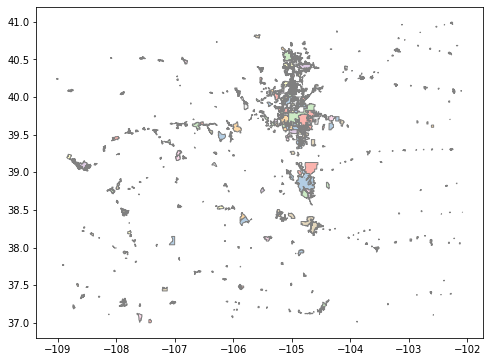

In [61]:
dft = gpd.read_file("/home/joe/bic_etl/dola/census/data_transformed/raw/places_2022/census_places.shp")
ax2 = dft.plot(figsize=(8,8), edgecolor=u'gray', cmap='Pastel1')

### State

In [62]:
state21 = pd.read_csv("Census_in_Colorado_2021_20240524.csv")
state22 = pd.read_csv("Census_in_Colorado_2022_20240528.csv")

In [63]:
state20 =  pd.read_csv("https://data.colorado.gov/resource/ekih-pydt.csv?$limit=10000")

In [65]:
print(state20.shape)
print(state21.shape)
print(state22.shape)

(1, 157)
(1, 157)
(1, 157)


In [40]:
state20.head()

,the_geom,geoname,geonum,pop,hispanic,white_nh,black_nh,ntvam_nh,asian_nh,hawpi_nh,other_nh,twoplus_nh,male,female,ageless5,age5_9,age10_14,age15_19,age20_24,age25_29,age30_34,age35_39,age40_44,age45_49,age50_54,age55_59,age60_64,age65_69,age70_74,age75_79,age80_84,age85pl,ageless18,age18_24,med_age,households,familyhh,nonfamhh,hhldralone,hhldr_naln,housing_un,occ_hu,vac_hu,owned,rented,pop25plus,nohsdipl,hsgrad_sc,bachl_hghr,med_hh_inc,med_fam_in,per_cap_in,med_yr_blt,med_c_rent,med_g_rent,med_hm_val,citz_birth,citz_nat,not_citz,born_in_co,brn_oth_st,ntv_b_o_us,foreign_b,pop_1p,same_house,same_cnty,same_state,diff_state,frm_abroad,wrkrs_16pl,car_all,car_alone,car_carpoo,public_trn,pt_bus,pt_other,bike,walk,tr_other,wrk_home,w_16pl_nh,t_less_10,t_10_19,t_20_29,t_30_39,t_40_59,t_60_pl,pop_3pl,enrolled,preschool,kndrgrtn,gr_1_4,gr_5_8,gr_9_12,undergrad,grad_prof,n_enrolled,blt_2010_p,b2000_2009,b1990_1999,b1980_1989,b1970_1979,b1960_1969,b1950_1959,b1940_1949,b1939_e,own_occ_hu,v_l_50k,v50k_100k,v100k_150k,v150k_200k,v200k_250k,v250k_300k,v300k_400k,v400k_500k,v500k_750k,v750k_1m,v_1m_plus,rnt_occ_hu,rntl400,r400t599,r600t799,r800t999,r1000t1249,r1250t1499,r1500t1999,r2000pl,rnocshr,ps_uni,ps_below,ps_bel150,tot_l18,puni_65pl,pov_l18,pov_65pl,avghhsize,hhi_l20k,hhi20_30,hhi30_40,hhi40_50,hhi50_60,hhi60_75,hhi75_100,hhi100_125,hhi125_150,hhi150_200,hhi200_pl,civ_ni_pop,disabled,pop16_pls,laborforce,civ_lf,emp,unemp,armedfrcs,not_lf,civ_ni_
0,"MULTIPOLYGON (((-109.060253 38.599328, -109.05...",Colorado,108,5684926.0,1231126.0,3837450.0,224190.0,29337.0,178265.0,7794.0,12208.0,164556.0,2862153.0,2822773.0,330939.0,348555.0,364153.0,362041.0,378484.0,449799.0,442474.0,410075.0,372950.0,363217.0,346765.0,370274.0,336863.0,289442.0,211526.0,131069.0,82872.0,93428.0,1259031.0,525141.0,36.9,2137402.0,1358903.0,778499.0,591783.0,186716.0,2361372.0,2137402.0,223970.0,1415324.0,722078.0,3900754.0,308785.0,1969116.0,1622853.0,75231.0,92752.0,39545.0,1984.0,1217.0,1335.0,369900,5145412.0,242460.0,297054.0,2405430.0,2647528.0,92454.0,539514.0,5625572.0,4635646.0,452500,279217.0,226020.0,32189.0,2919907.0,2378033.0,2127579.0,250454.0,82173.0,60707.0,21466.0,31729.0,81786.0,30977.0,315209.0,2604698.0,320056.0,748680.0,570703.0,464482.0,310380.0,190397.0,5491894.0,1388732.0,85282.0,66557.0,280968.0,285823.0,289991.0,298854.0,81257.0,4103162.0,195401.0,402776.0,396453.0,335700,420410.0,197068.0,175322.0,59957.0,178285.0,1415324.0,47109.0,39345.0,52701.0,91505.0,120452.0,140639.0,308772.0,236357.0,246351.0,75944.0,56149.0,722078.0,30390.0,25068.0,51191.0,79640.0,121595.0,120686.0,173263.0,95754.0,24491.0,5563823.0,544232.0,918369.0,1241717.0,792756.0,143390.0,58895.0,2.6,230300,146434.0,161245.0,155920.0,156526.0,214966.0,290253.0,229671.0,158981.0,186878.0,206228.0,5588760.0,603587.0,4568027.0,3115754.0,3079769.0,2937047.0,142722.0,35985.0,1452273.0,5588760.0


In [66]:
s20 = state20['geoname'].values.tolist()
s21 = state21['geoname'].values.tolist()
s22 = state22['geoname'].values.tolist()

print("20-21",set(s20)-set(s21))
print("21-20",set(s21)-set(s20))
print("22-20",set(s22)-set(s20))
print("20-22",set(s20)-set(s22))

20-21 set()
21-20 set()
22-20 set()
20-22 set()


In [68]:
hA,hB = compareData(state20,state22,s20,"geoname")

In [44]:
hA

{}

In [45]:
hB

{}